In [2]:
import os
import numpy as np
import rasterio
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import folium
from folium.features import GeoJsonTooltip
from pathlib import Path
from rasterio import features
from shapely.geometry import Polygon, MultiPolygon
import geopandas as gpd
import json



# In order to run this code change this path of the .tif file to the appropriate one.

bands,height,width = (4, 9725, 9348)
dtype = float32
crs = EPSG:32611
bounds = BoundingBox(left=369030.0, bottom=3718416.0, right=397074.0, top=3747591.0)


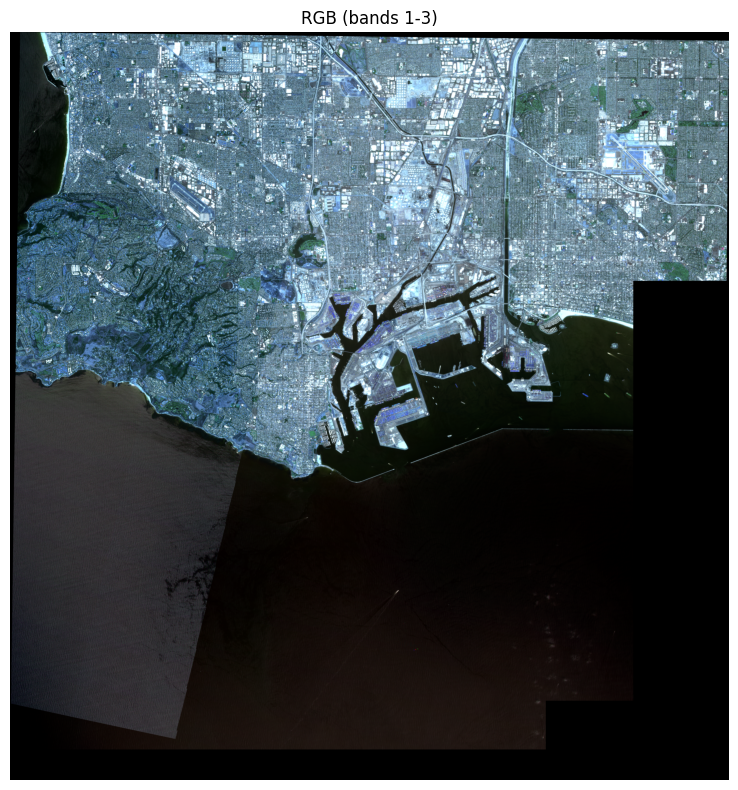

In [3]:
path = r"C:\Users\cpara\Desktop\CNN\merged_satellite.tif"

with rasterio.open(path) as src:
    arr = src.read()  
    print("bands,height,width =", arr.shape)
    print("dtype =", arr.dtype)
    print("crs =", src.crs)
    print("bounds =", src.bounds)


plt.figure(figsize=(10, 8))

if arr.shape[0] >= 3:
    
    rgb = np.moveaxis(arr[:3], 0, -1)  

    
    rgb = rgb.astype(np.float32)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

    plt.imshow(rgb)
    plt.title("RGB (bands 1-3)")
else:
    
    band = arr[0]
    plt.imshow(band, cmap="gray")
    plt.title("Single band")

plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
# -------------------------
# 1) Utils: tiling + pseudo labels
# -------------------------
def read_geotiff(path):
    with rasterio.open(path) as src:
        img = src.read()  
        meta = src.meta.copy()
        nodata = src.nodata
    return img, meta, nodata

def to_uint8_view(img):
    """
    Convert (bands,H,W) to uint8 for pseudo-labeling / visualization.
    If >=3 bands: use first 3 as RGB. If 1 band: use it.
    """
    if img.shape[0] >= 3:
        rgb = np.moveaxis(img[:3], 0, -1).astype(np.float32)  
        
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
        rgb_u8 = (rgb * 255).astype(np.uint8)
        gray = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2GRAY)
        return rgb_u8, gray
    else:
        band = img[0].astype(np.float32)
        p2, p98 = np.percentile(band, (2, 98))
        band = np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)
        gray_u8 = (band * 255).astype(np.uint8)
        rgb_u8 = np.repeat(gray_u8[..., None], 3, axis=-1)
        return rgb_u8, gray_u8

def nodata_mask_from_rgb(rgb_u8, thr=5):
    
    return (rgb_u8[...,0] < thr) & (rgb_u8[...,1] < thr) & (rgb_u8[...,2] < thr)

def pseudo_mask_land_water(gray_u8, nodata_mask):
    """
    1 = land (bright), 0 = water (dark). Ignore nodata areas by forcing to water=0.
    Uses Otsu on valid pixels only.
    """
    valid = (~nodata_mask).astype(np.uint8)
    vals = gray_u8[valid.astype(bool)]
    if vals.size < 1000:
        
        t = 127
    else:
        t, _ = cv2.threshold(vals, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    mask = (gray_u8 >= t).astype(np.uint8)  # 1 land, 0 water
    mask[nodata_mask] = 0

    
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    return mask

def tile_coords(H, W, tile=256, stride=256):
    coords = []
    for y in range(0, H - tile + 1, stride):
        for x in range(0, W - tile + 1, stride):
            coords.append((y, x))
    return coords


# -------------------------
# 2) Dataset
# -------------------------
class LandWaterDataset(Dataset):
    def __init__(self, tif_path, tile=256, stride=256):
        img, _, _ = read_geotiff(tif_path)
        self.img = img  # (bands,H,W)
        rgb_u8, gray_u8 = to_uint8_view(img)
        self.rgb_u8 = rgb_u8
        self.gray_u8 = gray_u8

        self.nodata = nodata_mask_from_rgb(rgb_u8)
        self.full_mask = pseudo_mask_land_water(gray_u8, self.nodata)

        H, W = gray_u8.shape
        self.coords = tile_coords(H, W, tile=tile, stride=stride)
        self.tile = tile

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        y, x = self.coords[idx]
        tile_rgb = self.rgb_u8[y:y+self.tile, x:x+self.tile]  
        tile_mask = self.full_mask[y:y+self.tile, x:x+self.tile]  

        
        img_t = torch.from_numpy(tile_rgb).permute(2,0,1).float() / 255.0  
        mask_t = torch.from_numpy(tile_mask).long()  

        
        if torch.rand(1).item() < 0.5:
            img_t = TF.hflip(img_t)
            mask_t = TF.hflip(mask_t)
        if torch.rand(1).item() < 0.5:
            img_t = TF.vflip(img_t)
            mask_t = TF.vflip(mask_t)

        return img_t, mask_t


# -------------------------
# 3) Small U-Net
# -------------------------
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class UNetSmall(nn.Module):
    def __init__(self, in_ch=3, n_classes=2, base=32):
        super().__init__()
        self.enc1 = conv_block(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bott = conv_block(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = conv_block(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = conv_block(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = conv_block(base*2, base)

        self.out = nn.Conv2d(base, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bott(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out(d1)


# -------------------------
# 4) Train
# -------------------------
def train_model(tif_path, out_pt="unet_land_water.pt", tile=256, stride=256, epochs=5, bs=8, lr=1e-3):
    ds = LandWaterDataset(tif_path, tile=tile, stride=stride)
    dl = DataLoader(ds, batch_size=bs, shuffle=True, num_workers=0)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = UNetSmall().to(device)

    ce = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5], device=device))
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for ep in range(1, epochs+1):
        losses = []
        for x, y in tqdm(dl, desc=f"Epoch {ep}/{epochs}"):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = ce(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        print(f"Epoch {ep}: loss={np.mean(losses):.4f}")

    torch.save(model.state_dict(), out_pt)
    print(f"Saved: {out_pt}")
    return out_pt


# -------------------------
# 5) Predict full mask + save GeoTIFF
# -------------------------
@torch.no_grad()
def predict_full_mask(tif_path, model_path, out_mask_tif="land_mask.tif", tile=256, stride=256):
    img, meta, _ = read_geotiff(tif_path)
    rgb_u8, _ = to_uint8_view(img)
    H, W, _ = rgb_u8.shape

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = UNetSmall().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # output buffers
    pred_sum = np.zeros((H, W), dtype=np.float32)
    pred_cnt = np.zeros((H, W), dtype=np.float32)

    coords = tile_coords(H, W, tile=tile, stride=stride)
    for y, x in tqdm(coords, desc="Predicting"):
        tile_rgb = rgb_u8[y:y+tile, x:x+tile]
        x_t = torch.from_numpy(tile_rgb).permute(2,0,1).float()[None] / 255.0
        x_t = x_t.to(device)

        logits = model(x_t)              
        probs = torch.softmax(logits, 1) 
        land = probs[0,1].cpu().numpy()  

        pred_sum[y:y+tile, x:x+tile] += land
        pred_cnt[y:y+tile, x:x+tile] += 1.0

    land_prob = pred_sum / np.maximum(pred_cnt, 1e-6)
    land_mask = (land_prob >= 0.5).astype(np.uint8)  # 1 land, 0 water

    # save as single-band GeoTIFF 
    out_meta = meta.copy()
    out_meta.update({"count": 1, "dtype": "uint8"})
    with rasterio.open(out_mask_tif, "w", **out_meta) as dst:
        dst.write(land_mask, 1)

    print(f"Saved mask GeoTIFF: {out_mask_tif}")


if __name__ == "__main__":
    tif_path = r"C:\Users\cpara\Desktop\CNN\merged_satellite.tif" # <--- change to your input path

    model_path = train_model(
        tif_path,
        out_pt="unet_land_water.pt",
        tile=256,
        stride=256,
        epochs=5,
        bs=8,
        lr=1e-3
    )

    predict_full_mask(
        tif_path,
        model_path,
        out_mask_tif="land_mask.tif",
        tile=256,
        stride=256
    )


Epoch 1/5: 100%|██████████| 167/167 [04:00<00:00,  1.44s/it]


Epoch 1: loss=0.1853


Epoch 2/5: 100%|██████████| 167/167 [04:02<00:00,  1.45s/it]


Epoch 2: loss=0.1111


Epoch 3/5: 100%|██████████| 167/167 [24:56<00:00,  8.96s/it]   


...

Epoch 4: loss=0.1009


Epoch 5/5: 100%|██████████| 167/167 [04:11<00:00,  1.50s/it]


Epoch 5: loss=0.0848
Saved: unet_land_water.pt


Predicting: 100%|██████████| 1332/1332 [01:30<00:00, 14.68it/s]


Saved mask GeoTIFF: land_mask.tif


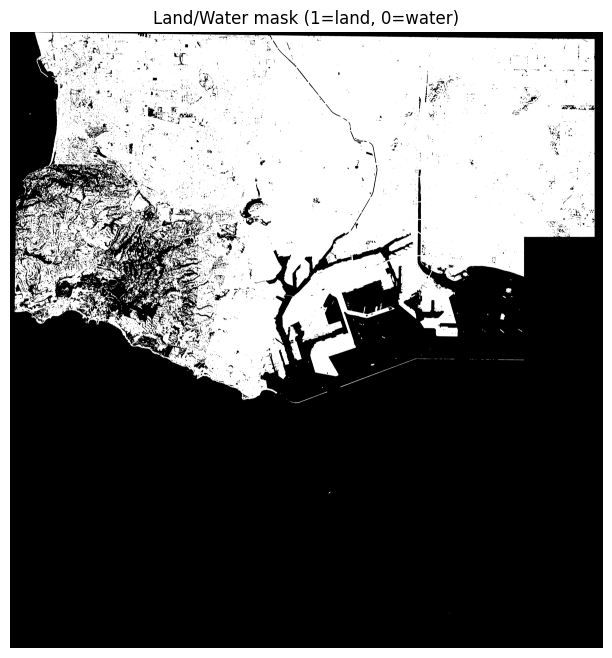

In [5]:
mask_path = r"land_mask.tif"  

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(mask, cmap="gray")   # 0 black, 1 white
plt.title("Land/Water mask (1=land, 0=water)")
plt.axis("off")
plt.show()


# Dont forget to change the path of the html input and output before you run the code

In [6]:
# ============================================================
# polygon_classify_from_html.ipynb 
# - Reads polygons from a Leaflet/Folium HTML
# - Uses your land_mask.tif (1=land, 0=water)
# - Classifies:
#     berthing  = touches land in at least one direction (ANY land in ring)
#     anchoring = surrounded by water (NO land in ring)
# - Saves:
#     C:\Users\cpara\Desktop\CNN\classified_polygons.geojson
#     C:\Users\cpara\Desktop\CNN\classified_polygons_map.html
# ============================================================

# ------------------------------------------------------------
# 1) Robust HTML polygon extraction 
# ------------------------------------------------------------
def extract_balanced(text: str, start_idx: int, open_ch: str, close_ch: str):
    """Return substring from first open_ch at/after start_idx until balanced close_ch."""
    s = text.find(open_ch, start_idx)
    if s == -1:
        return None
    depth = 0
    for i in range(s, len(text)):
        ch = text[i]
        if ch == open_ch:
            depth += 1
        elif ch == close_ch:
            depth -= 1
            if depth == 0:
                return text[s:i+1]
    return None


def _geojson_dict_to_geoms(gj: dict):
    """Convert GeoJSON dict to shapely geometries."""
    from shapely.geometry import shape
    out = []
    t = gj.get("type")
    if t == "FeatureCollection":
        for f in gj.get("features", []):
            g = f.get("geometry")
            if g:
                out.append(shape(g))
    elif t == "Feature":
        g = gj.get("geometry")
        if g:
            out.append(shape(g))
    elif "type" in gj and "coordinates" in gj:
        out.append(shape(gj))
    return out


def extract_leaflet_polygons_from_html(html_path: str):
    """
    Extract polygons from common Leaflet/Folium HTML patterns:
      - L.polygon([...])
      - L.geoJson({...})
      - embedded GeoJSON FeatureCollection objects
    Returns list of shapely geometries in HTML CRS (usually EPSG:4326).
    """
    text = Path(html_path).read_text(encoding="utf-8", errors="ignore")
    geoms = []

    # A) L.polygon([...])
    idx = 0
    while True:
        j = text.find("L.polygon", idx)
        if j == -1:
            break

        par = text.find("(", j)
        if par == -1:
            idx = j + 1
            continue

        arr = extract_balanced(text, par, "[", "]")
        if arr:
            try:
                coords = json.loads(arr)

                # Case 1: [[lat, lon], ...]
                if coords and isinstance(coords[0], list) and len(coords[0]) == 2 and isinstance(coords[0][0], (int, float)):
                    ring = [(pt[1], pt[0]) for pt in coords]  # (lon, lat)
                    geoms.append(Polygon(ring))

                # Case 2: [ [ [lat,lon],... ], [ [lat,lon],... ] ] (holes)
                elif coords and coords[0] and isinstance(coords[0][0], list) and len(coords[0][0]) == 2 and isinstance(coords[0][0][0], (int, float)):
                    rings = []
                    for ring_ll in coords:
                        rings.append([(pt[1], pt[0]) for pt in ring_ll])
                    geoms.append(Polygon(rings[0], holes=rings[1:] if len(rings) > 1 else None))

                # Case 3: MultiPolygon-ish nesting
                else:
                    polys = []
                    for poly in coords:
                        if poly and poly[0] and isinstance(poly[0][0], list):
                            outer = [(pt[1], pt[0]) for pt in poly[0]]
                            holes = [[(pt[1], pt[0]) for pt in hole] for hole in poly[1:]] if len(poly) > 1 else []
                            polys.append(Polygon(outer, holes=holes if holes else None))
                    if polys:
                        geoms.append(MultiPolygon(polys))

            except Exception:
                pass

        idx = j + 1

    # B) L.geoJson({...})
    idx = 0
    while True:
        j = text.find("L.geoJson", idx)
        if j == -1:
            break

        par = text.find("(", j)
        if par == -1:
            idx = j + 1
            continue

        obj = extract_balanced(text, par, "{", "}")
        if obj:
            try:
                gj = json.loads(obj)
                geoms.extend(_geojson_dict_to_geoms(gj))
            except Exception:
                pass

        idx = j + 1

    # C) Embedded FeatureCollection
    patterns = ['"type":"FeatureCollection"', '"type": "FeatureCollection"']
    hits = []
    for pat in patterns:
        start = 0
        while True:
            k = text.find(pat, start)
            if k == -1:
                break
            hits.append(k)
            start = k + 1

    for k in hits[:200]:
        start = text.rfind("{", 0, k)
        if start == -1:
            continue
        obj = extract_balanced(text, start, "{", "}")
        if not obj:
            continue
        try:
            gj = json.loads(obj)
            geoms.extend(_geojson_dict_to_geoms(gj))
        except Exception:
            continue

    geoms = [g for g in geoms if g.is_valid and not g.is_empty]
    return geoms


# ------------------------------------------------------------
# 2) Rasterize helper
# ------------------------------------------------------------
def rasterize_geom(geom, out_shape, transform, burn_value=1):
    return features.rasterize(
        [(geom, burn_value)],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )


# ------------------------------------------------------------
# 3) Classification rule
# ------------------------------------------------------------
def classify_polygon_berthing_vs_anchoring(
    land_mask: np.ndarray,  # 1=land, 0=water
    transform,
    polygon_geom,
    ring_buffer_m: float = 30.0
):
    outer = polygon_geom.buffer(ring_buffer_m)
    ring = outer.difference(polygon_geom)

    H, W = land_mask.shape
    ring_r = rasterize_geom(ring, (H, W), transform, burn_value=1).astype(bool)

    n = int(ring_r.sum())
    if n == 0:
        return ("unknown", False, np.nan, 0)

    touches_land = bool(((land_mask == 1) & ring_r).any())
    land_frac = float(((land_mask == 1) & ring_r).sum() / n)

    label = "berthing" if touches_land else "anchoring"
    return (label, touches_land, land_frac, n)


# ------------------------------------------------------------
# 4) Main: classify polygons from HTML + save GeoJSON 
# ------------------------------------------------------------
def classify_from_html(
    html_path: str,
    land_mask_tif: str,
    html_crs: str = "EPSG:4326",  
    ring_buffer_m: float = 30.0,
    out_geojson: str = r"C:\Users\cpara\Desktop\CNN\classified_polygons.geojson", 
    debug_print_bounds: bool = True
):
    with rasterio.open(land_mask_tif) as src:
        land_mask = src.read(1).astype(np.uint8)
        transform = src.transform
        raster_crs = src.crs  

    geoms = extract_leaflet_polygons_from_html(html_path)
    if not geoms:
        raise RuntimeError(
            "Found 0 geometries in HTML with the Leaflet/Folium parser. "
            "Search your HTML for 'L.polygon' or 'L.geoJson' to confirm the format."
        )

    if debug_print_bounds:
        print("n_geoms:", len(geoms))
        print("first geom bounds (HTML CRS):", geoms[0].bounds)
        print("raster_crs:", raster_crs)

    gdf = gpd.GeoDataFrame(geometry=geoms, crs=html_crs)
    gdf = gdf.to_crs(raster_crs)  # ensure meters for buffering

    labels, touches, land_fracs, ring_pixels = [], [], [], []
    for geom in gdf.geometry:
        label, t, lf, n = classify_polygon_berthing_vs_anchoring(
            land_mask=land_mask,
            transform=transform,
            polygon_geom=geom,
            ring_buffer_m=ring_buffer_m
        )
        labels.append(label)
        touches.append(t)
        land_fracs.append(lf)
        ring_pixels.append(n)

    gdf["spot_type"] = labels
    gdf["touches_land"] = touches
    gdf["land_frac_ring"] = land_fracs
    gdf["ring_pixels"] = ring_pixels

    # Save GeoJSON to your requested absolute path
    gdf.to_file(out_geojson, driver="GeoJSON")
    print(f"Saved GeoJSON: {out_geojson}")
    print(gdf["spot_type"].value_counts(dropna=False))

    return gdf


# ------------------------------------------------------------
# 5) Run (EDIT PATHS)
# ------------------------------------------------------------
html_path = r"C:\Users\cpara\Desktop\CNN\HTML\FINAL_Spectral.html" # <--- change to your input path
land_mask_tif = r"C:\Users\cpara\Desktop\CNN\land_mask.tif" # <--- change to your path

gdf = classify_from_html(
    html_path=html_path,
    land_mask_tif=land_mask_tif,
    html_crs="EPSG:4326",
    ring_buffer_m=30.0,
    out_geojson=r"C:\Users\cpara\Desktop\CNN\classified_polygons.geojson",
    debug_print_bounds=True
)


# ============================================================
# 6) Save an interactive HTML map 
# ============================================================


def save_classified_map_html(
    gdf,
    out_html=r"C:\Users\cpara\Desktop\CNN\HTML\Spectral_separate.html", # <--- change to your path
    tiles="OpenStreetMap"
):
    gdf_wgs = gdf.to_crs("EPSG:4326")

    minx, miny, maxx, maxy = gdf_wgs.total_bounds
    center_lat = float((miny + maxy) / 2)
    center_lon = float((minx + maxx) / 2)

    m = folium.Map(location=[center_lat, center_lon], tiles=tiles, zoom_start=12)

    def style_fn(feature):
        spot = feature["properties"].get("spot_type", "unknown")
        if spot == "berthing":
            return {"color": "orange", "weight": 2, "fillColor": "orange", "fillOpacity": 0.45}
        elif spot == "anchoring":
            return {"color": "deepskyblue", "weight": 2, "fillColor": "deepskyblue", "fillOpacity": 0.45}
        else:
            return {"color": "gray", "weight": 2, "fillColor": "gray", "fillOpacity": 0.30}

    fg_berth = folium.FeatureGroup(name="Berthing", show=True)
    fg_anchor = folium.FeatureGroup(name="Anchoring", show=True)
    fg_unknown = folium.FeatureGroup(name="Unknown", show=True)

    for name, sub, fg in [
        ("berthing", gdf_wgs[gdf_wgs["spot_type"] == "berthing"], fg_berth),
        ("anchoring", gdf_wgs[gdf_wgs["spot_type"] == "anchoring"], fg_anchor),
        ("unknown", gdf_wgs[gdf_wgs["spot_type"] == "unknown"], fg_unknown),
    ]:
        if len(sub) == 0:
            continue

        folium.GeoJson(
            sub.__geo_interface__,
            style_function=style_fn,
            tooltip=GeoJsonTooltip(
                fields=["spot_type", "touches_land", "land_frac_ring", "ring_pixels"],
                aliases=["Type", "Touches land", "Land frac ring", "Ring pixels"],
                localize=True,
                sticky=False
            ),
            name=name
        ).add_to(fg)

        fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.fit_bounds([[miny, minx], [maxy, maxx]])

    m.save(out_html)
    print(f"Saved HTML map: {out_html}")
    return m


m = save_classified_map_html(
    gdf,
    out_html=r"C:\Users\cpara\Desktop\CNN\HTML\Spectral_separate.html" # <--- change to your path
)


m


n_geoms: 80
first geom bounds (HTML CRS): (-118.2276976651566, 33.742722852932765, -118.2259199121259, 33.7453393559864)
raster_crs: EPSG:32611
Saved GeoJSON: C:\Users\cpara\Desktop\CNN\classified_polygons.geojson
spot_type
berthing     58
anchoring    22
Name: count, dtype: int64
Saved HTML map: C:\Users\cpara\Desktop\CNN\HTML\Spectral_separate.html
